<a href="https://colab.research.google.com/github/arobaseSuulei/edge-vision-model/blob/main/edge_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install tensorflow

In [32]:
import tensorflow as tf

In [33]:
!git clone https://huggingface.co/datasets/suuley/edge-vision-model

fatal: destination path 'edge-vision-model' already exists and is not an empty directory.


In [34]:
!ls

edge-vision-model  sample_data


In [35]:
!ls edge-vision-model/dataset

book  nothing  pc  pen	rename.py  shoes


In [36]:
import tensorflow as tf

DATASET_DIR="edge-vision-model/dataset"
IMG_SIZE=(96,96)
BATCH_SIZE=32

In [37]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=1,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2566 files belonging to 5 classes.
Using 2053 files for training.


In [38]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2566 files belonging to 5 classes.
Using 513 files for validation.


In [39]:
print("nbre de classes :", train_ds.class_names)
print("batches train :", len(train_ds))
print("batches val   :", len(val_ds))

nbre de classes : ['book', 'nothing', 'pc', 'pen', 'shoes']
batches train : 65
batches val   : 17


In [40]:
augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # image split horizontalement
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [41]:
normalization = tf.keras.layers.Rescaling(1./255)

In [47]:
for image,label in train_ds.take(1):
  print(image)
  print("")
  print(label)

tf.Tensor(
[[[[ 40.416668  69.33333   69.875   ]
   [ 41.5       65.625     67.5     ]
   [ 42.708332  60.75      64.75    ]
   ...
   [ 47.75003   79.91669   66.25006 ]
   [ 43.75      76.75      57.75    ]
   [ 40.625015  74.45833   50.95839 ]]

  [[ 55.        71.25      75.75    ]
   [ 56.375     70.375     75.625   ]
   [ 58.125     71.375     77.25    ]
   ...
   [ 63.66667   89.08333   77.6667  ]
   [ 61.75      88.        71.25    ]
   [ 58.416687  85.54167   64.25006 ]]

  [[ 56.208336  55.958332  66.333336]
   [ 54.75      59.5       68.25    ]
   [ 57.125     69.541664  75.666664]
   ...
   [ 67.750015  85.62501   76.750046]
   [ 65.        83.75      69.5     ]
   [ 62.416687  81.79167   63.25006 ]]

  ...

  [[ 50.25      79.        63.958336]
   [ 56.625     92.875     76.625   ]
   [ 64.45833  102.45833   89.125   ]
   ...
   [ 58.45835   74.45835   64.45835 ]
   [ 56.375     72.375     62.375   ]
   [ 54.79167   70.79167   60.79167 ]]

  [[ 55.083332  78.875     74.0833

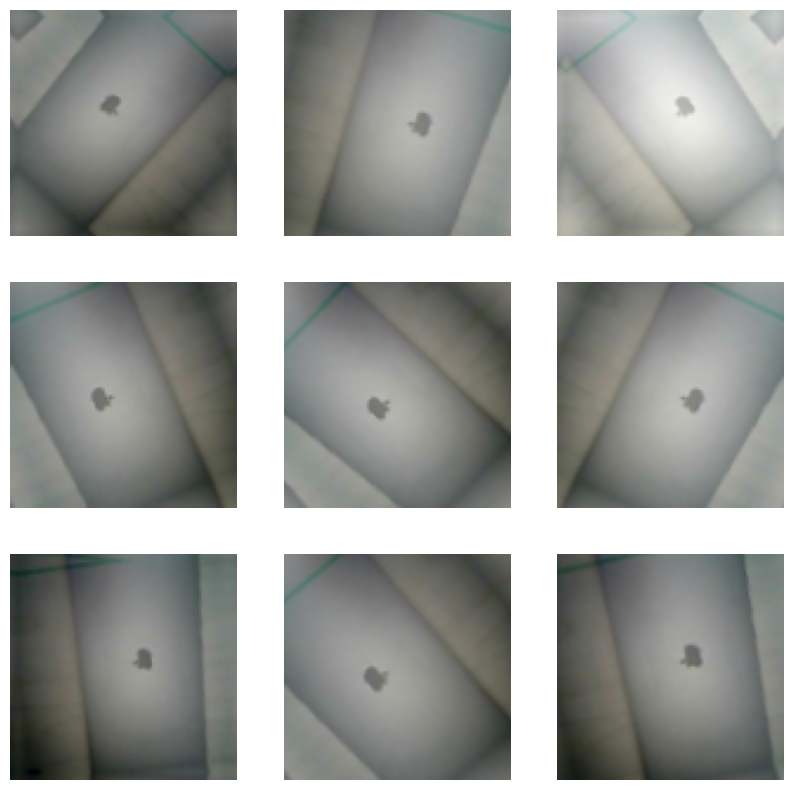

In [49]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    image = images[0]

    plt.figure(figsize=(10,10))

    for i in range(9):
        augmented_image = augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

    plt.show()